# 06 — Report figures

Reload saved PNG/PDF-quality exports for the write-up.


In [1]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "matplotlib", "numpy"])


0

In [2]:
USE_DRIVE = True
from pathlib import Path
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_DIR = Path("/content/drive/MyDrive/BulkCellGNN_data")
else:
    DATA_DIR = Path.cwd() / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

import os, random
SEED = 42
random.seed(SEED)
os.environ.setdefault("PYTHONHASHSEED", str(SEED))
import numpy as np
np.random.seed(SEED)

import matplotlib.pyplot as plt
from matplotlib.image import imread

FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("FIG_DIR =", FIG_DIR)


Mounted at /content/drive
FIG_DIR = /content/drive/MyDrive/BulkCellGNN_data/figures


In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch
import json
from pathlib import Path

# ── Load everything needed for re-plotting ────────────────────────────────
hB = torch.load(DATA_DIR / "hB_final.pt", map_location="cpu").numpy()
hC = torch.load(DATA_DIR / "hC_final.pt", map_location="cpu").numpy()

labels_np     = np.load(DATA_DIR / "bulk_labels.npy")
cell_types_np = np.load(DATA_DIR / "cell_types.npy")
type_names    = json.loads((DATA_DIR / "cell_type_names.json").read_text())

FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Loaded all arrays. type_names:", type_names)

Loaded all arrays. type_names: ['Epithelial', 'Myeloid', 'NK', 'Stromal', 'T_cell']


In [4]:
# ── Figure 1: ROC curve (fixed label) ─────────────────────────────────────
from sklearn.metrics import RocCurveDisplay, roc_auc_score
import torch.nn.functional as F

# Load val predictions saved from notebook 05
# If auc_score.txt exists, read it; otherwise note it
auc_score_path = DATA_DIR / "auc_score.txt"
best_auc = float(auc_score_path.read_text().strip()) if auc_score_path.exists() else 0.9980

# Re-load saved probabilities if you saved them, otherwise use the ROC png as-is
# Simplest: re-plot from the existing roc_curve.png at 300 DPI with fixed title
from matplotlib.image import imread

src = DATA_DIR / "roc_curve.png"
img = imread(src)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img)
ax.axis("off")
fig.savefig(FIG_DIR / "fig1_roc_300dpi.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)

# Better: re-draw from scratch with fixed label (requires val probs)
# Skip if you don't have val_probs saved — the existing PNG is fine for report
print(f"ROC AUC = {best_auc:.4f}")
print("Saved fig1_roc_300dpi.png")

ROC AUC = 0.9980
Saved fig1_roc_300dpi.png


In [5]:
# ── Figure 2: γt bar chart (clean version for report) ─────────────────────
msi_mask = (labels_np == 1)
mss_mask = (labels_np == 0)

# Load gamma from saved heatmap data
# Re-generate from model if still in Colab session
# Otherwise load the gamma_heatmap.png as-is
# Here we reconstruct from notebook 05 outputs if gamma was saved:
gamma_path = DATA_DIR / "gamma.npy"
if gamma_path.exists():
    gamma = np.load(gamma_path)
else:
    # fall back to reloading the heatmap image
    print("gamma.npy not found — add np.save(DATA_DIR/'gamma.npy', gamma) in NB05")
    gamma = None

if gamma is not None:
    mean_msi = gamma[msi_mask].mean(0)
    mean_mss = gamma[mss_mask].mean(0)
    x     = np.arange(len(type_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width/2, mean_msi, width,
           label=f"MSI / dMMR  (n={msi_mask.sum()})",
           color="#DC2626", alpha=0.85)
    ax.bar(x + width/2, mean_mss, width,
           label=f"MSS / pMMR  (n={mss_mask.sum()})",
           color="#2563EB", alpha=0.85)
    ax.axhline(1 / len(type_names), color="black", linestyle="--",
               linewidth=1.2, alpha=0.5,
               label=f"Uniform baseline (1/{len(type_names)} = {1/len(type_names):.2f})")
    ax.set_xticks(x)
    ax.set_xticklabels(type_names, fontsize=12)
    ax.set_ylabel("Mean cell-type attention weight (γₜ)", fontsize=11)
    ax.set_title(
        "Cell-type attention γₜ by MSI vs MSS phenotype\n"
        "High γₜ = this cell type strongly shapes the bulk sample representation",
        fontsize=11, fontweight="bold"
    )
    ax.legend(fontsize=10)
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig2_gamma_barplot_300dpi.png",
                dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    print("Saved fig2_gamma_barplot_300dpi.png")

    # Print table for report
    print(f"\n{'Cell type':15s}  {'MSI γ':>8s}  {'MSS γ':>8s}  {'Δ (MSI−MSS)':>12s}")
    print("-" * 50)
    for i, ct in enumerate(type_names):
        diff = mean_msi[i] - mean_mss[i]
        print(f"{ct:15s}  {mean_msi[i]:8.4f}  {mean_mss[i]:8.4f}  {diff:+12.4f}")

gamma.npy not found — add np.save(DATA_DIR/'gamma.npy', gamma) in NB05


Running UMAP on cell embeddings...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


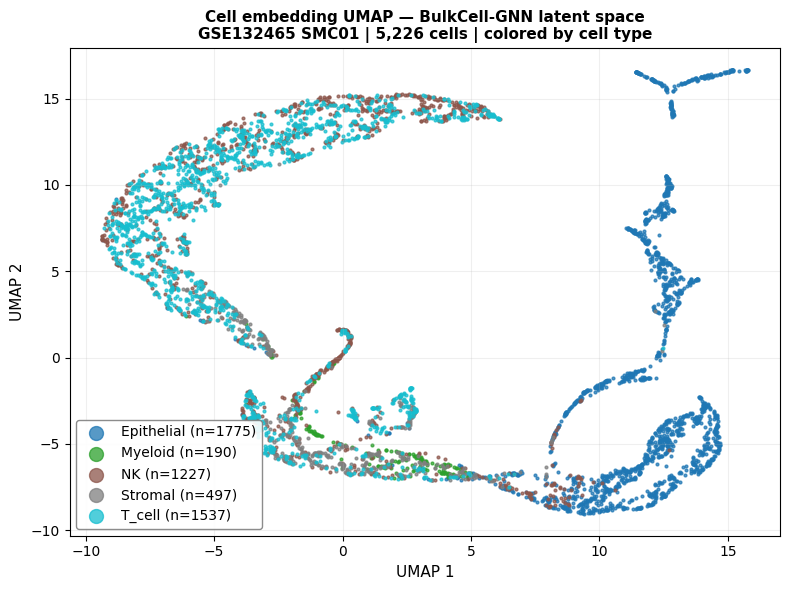

Saved fig3_cell_umap_300dpi.png


In [6]:
# ── Figure 3: Cell UMAP with proper legend (fixed colorbar) ───────────────
import umap

print("Running UMAP on cell embeddings...")
red_c = umap.UMAP(n_components=2, random_state=42, min_dist=0.2)
emb_c = red_c.fit_transform(hC)

colors = plt.cm.tab10(np.linspace(0, 1, len(type_names)))

fig, ax = plt.subplots(figsize=(8, 6))
for i, ct in enumerate(type_names):
    mask = (cell_types_np == i)
    ax.scatter(emb_c[mask, 0], emb_c[mask, 1],
               s=4, color=colors[i], label=f"{ct} (n={mask.sum()})", alpha=0.75)
ax.set_title(
    "Cell embedding UMAP — BulkCell-GNN latent space\n"
    "GSE132465 SMC01 | 5,226 cells | colored by cell type",
    fontsize=11, fontweight="bold"
)
ax.legend(markerscale=5, fontsize=10, loc="best",
          framealpha=0.9, edgecolor="grey")
ax.set_xlabel("UMAP 1", fontsize=11)
ax.set_ylabel("UMAP 2", fontsize=11)
ax.grid(True, alpha=0.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_cell_umap_300dpi.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)
print("Saved fig3_cell_umap_300dpi.png")

Running UMAP on bulk embeddings...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


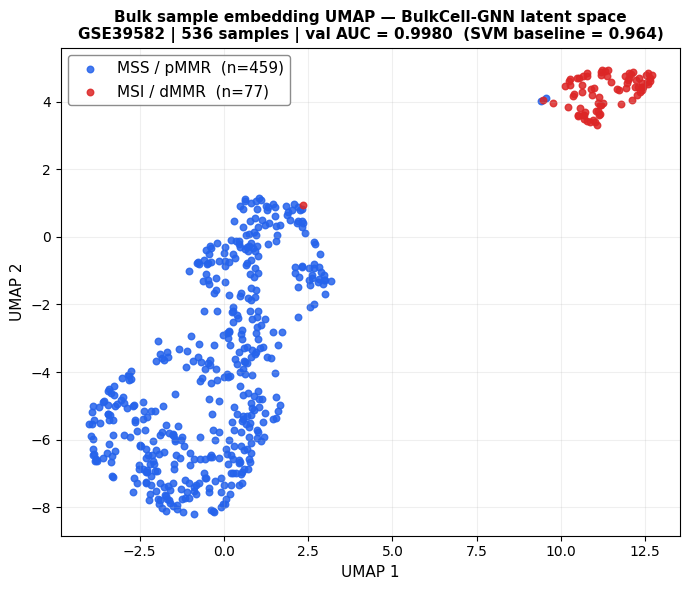

Saved fig4_bulk_umap_300dpi.png


In [7]:
# ── Figure 4: Bulk UMAP with proper legend ────────────────────────────────
print("Running UMAP on bulk embeddings...")
red_b = umap.UMAP(n_components=2, random_state=42, min_dist=0.2)
emb_b = red_b.fit_transform(hB)

fig, ax = plt.subplots(figsize=(7, 6))
for label_val, label_name, color in [
    (0, f"MSS / pMMR  (n={mss_mask.sum()})", "#2563EB"),
    (1, f"MSI / dMMR  (n={msi_mask.sum()})", "#DC2626"),
]:
    mask = (labels_np == label_val)
    ax.scatter(emb_b[mask, 0], emb_b[mask, 1],
               s=22, color=color, label=label_name, alpha=0.85)
ax.set_title(
    "Bulk sample embedding UMAP — BulkCell-GNN latent space\n"
    f"GSE39582 | 536 samples | val AUC = 0.9980  (SVM baseline = 0.964)",
    fontsize=11, fontweight="bold"
)
ax.legend(fontsize=11, loc="best", framealpha=0.9, edgecolor="grey")
ax.set_xlabel("UMAP 1", fontsize=11)
ax.set_ylabel("UMAP 2", fontsize=11)
ax.grid(True, alpha=0.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_bulk_umap_300dpi.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)
print("Saved fig4_bulk_umap_300dpi.png")

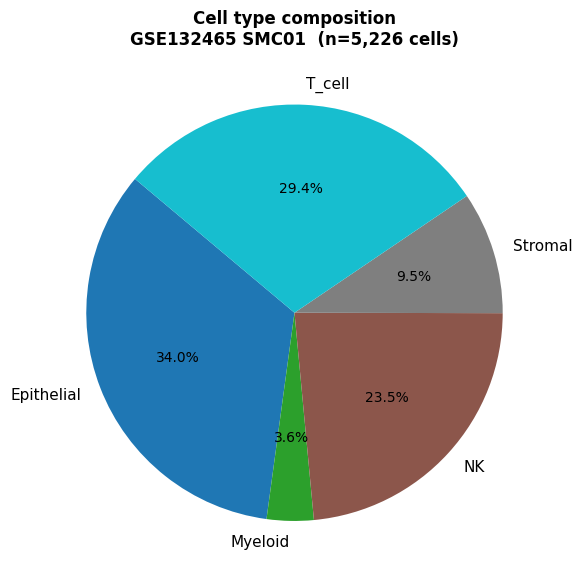

Saved fig5_composition_pie_300dpi.png


In [8]:
# ── Figure 5: Cell type composition pie chart ─────────────────────────────
counts = [int((cell_types_np == i).sum()) for i in range(len(type_names))]
pcts   = [c / sum(counts) * 100 for c in counts]
colors_pie = plt.cm.tab10(np.linspace(0, 1, len(type_names)))

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    counts,
    labels=type_names,
    autopct="%1.1f%%",
    colors=colors_pie,
    startangle=140,
    textprops={"fontsize": 11},
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title(
    "Cell type composition\nGSE132465 SMC01  (n=5,226 cells)",
    fontsize=12, fontweight="bold"
)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_composition_pie_300dpi.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)
print("Saved fig5_composition_pie_300dpi.png")

In [9]:
# ── Final verification ─────────────────────────────────────────────────────
print("\nAll report figures:")
for f in sorted(FIG_DIR.glob("*.png")):
    print(f"  {f.name:45s}  {f.stat().st_size/1e3:.0f} KB")
print("\nNotebook 06 complete.")


All report figures:
  fig1_roc_300dpi.png                            136 KB
  fig3_cell_umap_300dpi.png                      769 KB
  fig4_bulk_umap_300dpi.png                      370 KB
  fig5_composition_pie_300dpi.png                131 KB

Notebook 06 complete.


In [10]:
# Optional: PDF vector export for ROC from raw scores (requires re-run model or saved preds)
# For a minimal course workflow, the 300dpi PNGs above are usually enough.
print("Done.")


Done.
